In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
from scipy import stats

In [16]:
##Connecting database

db_path = os.path.expanduser('~/Desktop/olist_ecommerce_sql_analysis/olist.db')
conn = sqlite3.connect(db_path)
print("File exists:", os.path.exists(db_path))
print("Resolved path:", db_path)


File exists: True
Resolved path: /Users/mac/Desktop/olist_ecommerce_sql_analysis/olist.db


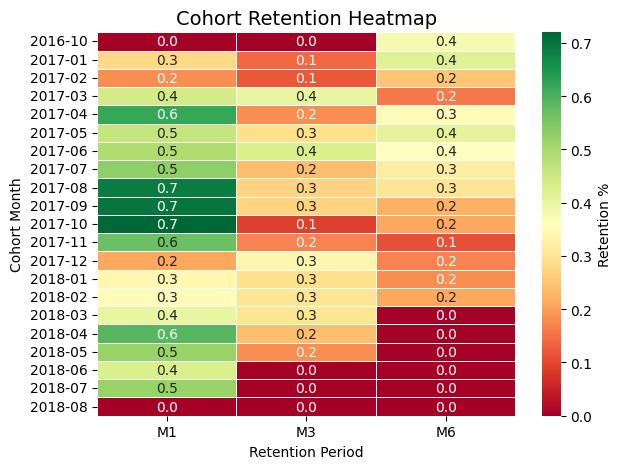

In [71]:
df = pd.read_sql_query("""WITH first_purchase AS (
SELECT c.customer_unique_id, 
       MIN(o.order_purchase_timestamp) AS first_order,
       STRFTIME('%Y-%m',MIN( o.order_purchase_timestamp)) AS cohort_month
FROM olist_customers_dataset c
JOIN olist_orders_dataset o
ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
),

all_purchases AS (
SELECT c.customer_unique_id, 
       STRFTIME('%Y-%m', o.order_purchase_timestamp) AS purchase_month
FROM olist_customers_dataset c
JOIN olist_orders_dataset o
ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id, purchase_month
),

cohort_data AS (
SELECT f.customer_unique_id, f.cohort_month, a.purchase_month,
        ((CAST(SUBSTR(a.purchase_month, 1,4)AS INTEGER) - 
        CAST(SUBSTR(f.cohort_month, 1,4)AS INTEGER)) * 12) +
        (CAST(SUBSTR(a.purchase_month, 6,2)AS INTEGER) - 
         CAST(SUBSTR(f.cohort_month, 6,2)AS INTEGER))  AS returning_month
FROM first_purchase f
JOIN all_purchases a
On f.customer_unique_id = a.customer_unique_id
-- Excluded to prevent NULL rows for cohorts with no returning customers; does not affect m1/m3/m6 results
--WHERE f.cohort_month != a.purchase_month
),

cohort_size AS(
SELECT cohort_month, COUNT(*) AS total_customers
FROM first_purchase f
GROUP BY cohort_month
HAVING COUNT(*) >= 10
)

SELECT c.cohort_month, s.total_customers,
       ROUND(((SUM(CASE WHEN c.returning_month = 1 THEN 1 ELSE 0 END))*100.0)/s.total_customers,2) AS retention_m1,
       ROUND(((SUM( CASE WHEN c.returning_month = 3 THEN 1 ELSE 0 END))*100.0)/s.total_customers,2) AS retention_m3,
       ROUND(((SUM( CASE WHEN c.returning_month = 6 THEN 1 ELSE 0 END))*100.0)/s.total_customers,2) AS retention_m6
       
FROM cohort_size s
LEFT JOIN cohort_data c
ON c.cohort_month = s.cohort_month
WHERE s.total_customers >= 10 
GROUP BY c.cohort_month
ORDER BY c.cohort_month;

""",conn)

heatmap_data = df.set_index('cohort_month')[['retention_m1', 'retention_m3', 'retention_m6']]
heatmap_data.columns = ['M1', 'M3', 'M6']
sns.heatmap(heatmap_data, annot = True, fmt = '.1f', cmap = 'RdYlGn', linewidths = 0.5, cbar_kws={'label': 'Retention %'})
plt.title('Cohort Retention Heatmap', fontsize=14)
plt.xlabel('Retention Period')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
#Note: 0.0% values in later cohorts reflect insufficient time elapsed within the dataset period, not actual zero retention.